# Get Bio-ARGO data
**Author:** Eli Holmes (NOAA)</br>
Last updated: November 21, 2025

>📘 Learning Objectives
>
> 1. Get [Argo data](https://www.aoml.noaa.gov/argo) using the [argopy](https://pypi.org/project/argopy/) Python package
> 2. Learn the basic format of the data grouped into platform and cycles
> 3. Learn how to filter to just surface data
> 4. Learn how to get data in batches

Biogeochemical Argo (“Bio-Argo” or BGC-Argo) floats are autonomous profiling instruments that drift with ocean currents and periodically dive from the surface to depths of 1,000–2,000 meters, collecting a vertical profile of physical and biogeochemical properties. These floats are all over the world's oceans and the data are freely available via the Argo global data assembly centers (GDACs) [Video on the Argo system](https://youtu.be/IixnxfysYAE?si=5xcPe6wa3LoWqUL3).

Each float has a unique PLATFORM_NUMBER, and every time it dives and returns to the surface it produces a new profile, identified by its CYCLE_NUMBER. A single float may produce hundreds of profiles over several years. Bio-Argo floats carry optical, chemical, and physical sensors that measure variables such as chlorophyll-a (CHLA), temperature (TEMP), salinity (PSAL), pressure (PRES, which is used as depth), dissolved oxygen (DOXY), and nitrate (NITRATE). These data are distributed in a consistent, profile-based format: each profile (platform+cycle) contains measurements at multiple depths, along with time, latitude, longitude, and quality-control flags. To use these data for surface-matching with satellite products, we will extract the shallow measurements from each profile (pressure is less than 20dbar or 10dbar). We will use the [argopy](https://pypi.org/project/argopy/) package to download Argo data from the [Coriolis Argo Global Assembly Center](https://coriolis-93c5db.gitlab-pages.ifremer.fr/).

![](Supporting_files/argo_float_cycle.png)

## Workflow

Here is our basic workflow.

1. Use `argopy` to fetch data for Bio-Argo profiles in a given region and time
3. For each profile, save one point, the shallowest reading.
4. Process the globe in monthly chunks to not overload the ERDDAP server and save the monthly shallow points to a parquet file.

In [2]:
!pip install argopy

## Step 1. Get some data

In this first step we’ll grab some in-situ data from Bio-Argo floats. We use `argopy`’s `ArgoDataFetcher` function to set up a datafetcher object with the information on what dataset (`ds` arg), where (`src` arg) and what parameters. We can access data by a specific buoy (platform), cycle (one descending/ascending cycle of a float), or by region (any data in that region, depth, time). We will use region. Once we set up our datafetcher object, we request the data using a method like `to_xarray()` or `to_dataframe()` to get the data and return in a specific form. We will use `to_xarray()` because the processing by buoy/cycle to get the shallowest points will be easier using xarray.

The code below requests only chlorophyll (CHLA) and pressure (PRES) for March 2024 in our chosen region and returns the result as an xarray Dataset that we can later save as a parquet file.

In [3]:
# get some data
from argopy import DataFetcher as ArgoDataFetcher
# specify the data set and what source
fetcher = ArgoDataFetcher(
    ds="bgc",
    src="erddap",
    params=["CHLA", "PRES"] # both these need to be present
)
# specify that we want to access data in a region; a NW Atlantic box
# lon_min, lon_max, lat_min, lat_max, depth_min, depth_max, time_min, time_max
region = [-70, -40, 20, 60, 0, 1000, "2024-03-01", "2024-04-01"]
fetcher = fetcher.region(region)
fetcher

<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo BGC data fetcher for a space/time region
🗺  Domain: [x=-70.00/-40.00; y=20.00/60.00; z=0.0/1000.0; t=2024-03-01/2024-04-01]
🔗 API: https://erddap.ifremer.fr/erddap
📗 Parameters: ['CHLA', 'PRES', 'TEMP', 'PSAL']
📕 BGC 'must be measured' parameters: []
🏊 User mode: standard
🟢 Dataset: bgc-s
🌥  Performances: cache=False, parallel=False

In [4]:
# Get the data using the to_xarray() method
ds_na = fetcher.to_xarray()

In [4]:
ds_na

<xarray.Dataset> Size: 1MB
Dimensions:          (N_POINTS: 9267)
Coordinates:
    LATITUDE         (N_POINTS) float64 74kB 27.53 35.76 23.02 ... 39.93 26.89
    LONGITUDE        (N_POINTS) float64 74kB -50.32 -56.92 ... -68.26 -50.2
    TIME             (N_POINTS) datetime64[ns] 74kB 2024-03-01T05:16:51.00099...
  * N_POINTS         (N_POINTS) int64 74kB 0 1 2 3 4 ... 9263 9264 9265 9266
Data variables: (12/21)
    CHLA             (N_POINTS) float32 37kB 0.0036 0.0036 ... 0.005341 0.0
    CHLA_DATA_MODE   (N_POINTS) <U1 37kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    CHLA_ERROR       (N_POINTS) float32 37kB 0.0072 0.0072 0.02847 ... nan 0.0
    CHLA_QC          (N_POINTS) int64 74kB 1 1 5 5 5 5 5 5 5 ... 1 1 1 1 1 1 1 1
    CYCLE_NUMBER     (N_POINTS) int64 74kB 107 103 78 78 78 ... 21 21 21 21 110
    DIRECTION        (N_POINTS) <U1 37kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    ...               ...
    PSAL_QC          (N_POINTS) int64 74kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 37kB 7.259 7.285 24.82 ... 4.812 7.062
    TEMP_DATA_MODE   (N_POINTS) <U1 37kB 'D' 'D' 'A' 'A' 'A' ... 'R' 'R' 'R' 'D'
    TEMP_ERROR       (N_POINTS) float32 37kB 0.002 0.002 nan ... nan nan 0.002
    TEMP_QC          (N_POINTS) int64 74kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 74kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO-BGC
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           jovyan
    Fetched_date:         2025/11/28
    Fetched_constraints:  [x=-70.00/-40.00; y=20.00/60.00; z=0.0/1000.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [CHLA,PRES,PSAL,TEMP] real-time and adjusted/delaye...

In [5]:
# How many row in our dataframe?
df = ds_na.to_dataframe().reset_index()
df.shape[0]

9267

### Plot the data

/srv/conda/envs/notebook/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/srv/conda/envs/notebook/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


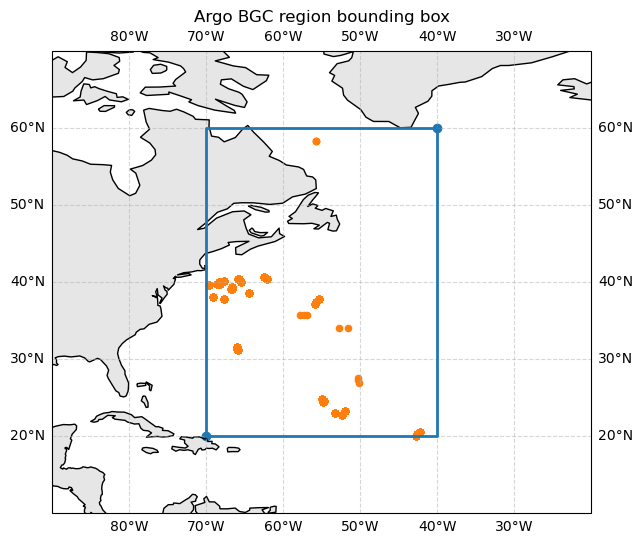

In [5]:
# plot the data; includes all buoys and all depths during each cycle
lon_min, lon_max, lat_min, lat_max = region[:4]
ds = ds_na

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Corners of the box (closed loop)
lons = [lon_min, lon_max, lon_max, lon_min, lon_min]
lats = [lat_min, lat_min, lat_max, lat_max, lat_min]

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Show a bit more context than just the box
ax.set_extent([lon_min - 20, lon_max + 20, lat_min - 10, lat_max + 10], crs=proj)

# Add coastlines and land
ax.coastlines(resolution="110m")
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

# Plot the bounding box
ax.plot(lons, lats, transform=proj, linewidth=2)
ax.scatter([lon_min, lon_max], [lat_min, lat_max], transform=proj)

# Add the Argo points from ds
ax.scatter(
    ds["LONGITUDE"].values,
    ds["LATITUDE"].values,
    s=20,
    marker="o",
    transform=proj,
)

ax.set_title("Argo BGC region bounding box")

plt.show()



### Profiles: a descending/ascending cycle

The data for each buoy are organized into cycles which is data collected on one descending/ascending cycle. Depending how the buoy is set up to record data, it might record only on the descending or ascending part of the cycle. The data that the ocean color satellites measure is just the surface. Even if there is high CHLA in deep water, the satellite does not "see" that. Thus we need to filter our cycle data from just the upper layer (< 20 m or so).

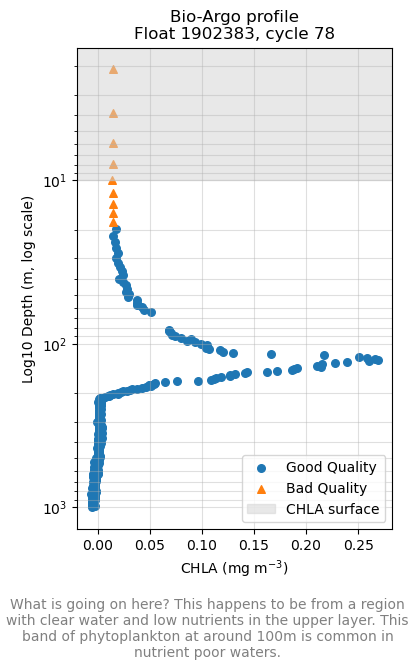

In [4]:
import numpy as np
import matplotlib.pyplot as plt

ds = ds_na  # just to keep the name short

# Unique platform numbers in the dataset
platforms = np.unique(ds["PLATFORM_NUMBER"].values)
plat = int(platforms[0])

# All cycles for that platform
cycles = ds["CYCLE_NUMBER"].where(ds["PLATFORM_NUMBER"] == plat, drop=True)
cycles = np.unique(cycles.values)
cyc = int(cycles[0])

# Select all points belonging to that profile
prof = ds.where(
    (ds["PLATFORM_NUMBER"] == plat) & (ds["CYCLE_NUMBER"] == cyc),
    drop=True
)

chl   = prof["CHLA"]
pres  = prof["PRES"]
qc = prof["CHLA_QC"]   # 'A' or 'D'

# Depth in meters ~ pressure in dbar
depth = pres
depth_plot = depth.clip(min=1)  # avoid 0 for log scale

# Masks for ascending/descending
good_mask =  qc.isin([1, 2])
bad_mask = ~good_mask

fig, ax = plt.subplots(figsize=(4, 6))

# Plot descending profile
ax.scatter(
    chl.where(good_mask),
    depth_plot.where(good_mask),
    label="Good Quality",
    s=30,
)

# Plot ascending profile
ax.scatter(
    chl.where(bad_mask),
    depth_plot.where(bad_mask),
    label="Bad Quality",
    s=30,
    marker="^",
)

# Add a shaded layer representing what is often designated as CHLA surface (e.g. 0–10 m)
z_sat = 10  # meters; adjust to taste for your explanation
ax.axhspan(0, z_sat, color="lightgrey", alpha=0.5,
           label="CHLA surface")

# Log scale on depth axis, surface at top
ax.set_yscale("log")
ax.invert_yaxis()

ax.set_xlabel("CHLA (mg m$^{-3}$)")
ax.set_ylabel("Log10 Depth (m, log scale)")
ax.set_title(f"Bio-Argo profile\nFloat {plat}, cycle {cyc}")
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="lower right")
plt.figtext(0.5, -0.1, "What is going on here? This happens to be from a region with clear water and low nutrients in the upper layer. This band of phytoplankton at around 100m is common in nutrient poor waters.",
            wrap=True, horizontalalignment='center', fontsize=10, color='gray')

# Adjust the bottom margin to make space for the annotation if necessary
#fig.subplots_adjust(bottom=0.25) # Increase bottom margin if annotation is cut off

plt.tight_layout()
plt.show()


## Step 2 Compute point estimates

We will compute two point estimates from the profiles of CHLA: 1) the surface average from 0 to 10m and 2) binned averages from 0 to 200m in bins 10m wide. We will not be filtering based on CHLA_QC so as to not lose too much data.

### Create functions to make these calculations from a profile

In [5]:
# average over a depth band
def average_profile(depth, var, z_min=0.0, z_max=None):
    """
    Average a var profile over a depth range.

    Parameters
    ----------
    depth : array-like
        1D array of depth or pressure (m or dbar ≈ m), increasing downward.
    var : array-like
        1D array of variable same shape as `depth`.
    z_min : float, optional
        Lower bound of depth (e.g. 0 for surface), in same units as depth.
    z_max : float or None, optional
        Upper bound of depth. If None, use max(depth).

    Returns
    -------
    Mean of var [z_min, z_max]. Returns np.nan if insufficient data.
    Number of data points in [z_min, z_max].
    """
    depth = np.asarray(depth, dtype=float)
    var   = np.asarray(var,   dtype=float)

    # Mask out NaNs
    m = np.isfinite(depth) & np.isfinite(var)
    depth = depth[m]
    var   = var[m]

    if depth.size < 1:
        return np.nan, 0

    # Set z_max if not provided
    if z_max is None:
        z_max = depth.max()

    # Subset to [z_min, z_max]
    sel = (depth > z_min) & (depth <= z_max)
    depth = depth[sel]
    var   = var[sel]

    if depth.size < 1:
        return np.nan, 0

    # Mean
    return np.mean(var), len(var)

In [6]:
# function to create our metrics for a platform/cycle group
import numpy as np
import pandas as pd

def summarize_profile_binned(group, var, depth_bins=None, include_meta=False):
    """
    Summarize a single Bio-Argo profile into depth-binned CHL means and one integrated bin.
    Returns pd.Series with one row with CHL in each depth bin + metadata.
    """
    depth_bins = np.arange(0, 210, 10)  # 0,10,...,200

    z = group["PRES"].values
    c = group[var].values

    out = {}

    if include_meta:# metadata
        out["TIME"]      = group["TIME"].iloc[0]
        out["LATITUDE"]  = group["LATITUDE"].iloc[0]
        out["LONGITUDE"] = group["LONGITUDE"].iloc[0]

    # depth-binned means
    for z0, z1 in zip(depth_bins[:-1], depth_bins[1:]):
        col1 = f"{var}_{int(z0)}_{int(z1)}"
        col2 = f"{var}_{int(z0)}_{int(z1)}_N"
        out[col1], out[col2] = average_profile(z, c, z_min=z0, z_max=z1)

    return pd.Series(out)

In [13]:
# test that functions work

df = ds_na.to_dataframe().reset_index()

# QC first
df_qc = df[df["CHLA_QC"].isin([1, 2])]

df_points = (
    df_qc
    .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
    .apply(summarize_profile_binned, var="CHLA", include_meta=True, include_groups=False)   # default 0–200m in 10m bins
    .reset_index(drop=True)
)

In [14]:
df_points.head()

,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_0_10,CHLA_0_10_N,CHLA_10_20,CHLA_10_20_N,CHLA_20_30,...,CHLA_150_160,CHLA_150_160_N,CHLA_160_170,CHLA_160_170_N,CHLA_170_180,CHLA_170_180_N,CHLA_180_190,CHLA_180_190_N,CHLA_190_200,CHLA_190_200_N
0,1902383,78,2024-03-02 16:13:24.002000128,23.0209,-53.2220,NaN,0,0.017404,1,0.016929,...,0.129163,5,0.101144,5,0.054446,5,0.042098,5,0.024844,5
1,1902383,79,2024-03-12 15:19:00.002000128,22.7279,-52.3932,0.011863,1,0.013578,6,0.012971,...,0.126472,5,0.095604,5,0.058087,5,0.041782,5,0.025952,5
2,1902383,80,2024-03-22 15:28:33.002000128,23.2649,-52.0005,NaN,0,0.023577,5,0.015662,...,0.065052,5,0.057928,5,0.062677,5,0.045739,5,0.027851,5
3,1902384,79,2024-03-08 20:58:18.002000128,20.0154,-42.7101,0.027295,5,0.028305,5,0.029748,...,0.136242,5,0.112432,5,0.074770,5,0.042880,5,0.028594,5
4,1902384,80,2024-03-18 20:31:41.002000128,20.3018,-42.5525,0.016256,4,0.018060,5,0.019359,...,0.201177,5,0.124553,5,0.078233,5,0.050095,5,0.037541,5


## Put it together to process the globe

Those are the 2 steps that we will do for each part of the globe and each month since March 2024. We create a function that combines these 2 steps to get one month of data for a region and then we use a for loop to work through the globe. We save the processed monthly data.

### A function to get one month

Get a month for a region. Return a dataframe of the shallow points only. The function allows us to get multiple possible variables like CHLA, DOXY, NITRATE, BBP770, TEMP and PSAL. However if we pass in multiple variables then all must be present, so to maximize the data only pass in one varible at a time unless you need paired measurements.

In [232]:
# get_bgc_surface() function
from pathlib import Path

import numpy as np
import pandas as pd
from argopy import DataFetcher as ArgoDataFetcher


def get_bgc_profile(reg, mon, data_dir="data", vars=None, save=False):
    """
    Fetch profile Bio-Argo data by 10m for a region and month and (optionally) save as parquet.

    Parameters
    ----------
    reg : sequence
        [lon_min, lon_max, lat_min, lat_max, depth_min, depth_max]
        (same as argopy region, but without time bounds).
    mon : str or datetime-like
        Month to fetch, e.g. "2024-03" or "2024-03-01".
    data_dir : str, optional
        Directory where the parquet file will be saved.
    vars : list of str, optional
        Bio-Argo variables to fetch and surface-average (e.g. ["CHLA", "BBP700", "DOXY"]).
        Defaults to ["CHLA"].
    save : bool, optional
        If True, save a parquet file and return (df_surf, path).
        If False, just return (df_surf, None).

    Returns
    -------
    df_surf : pandas.DataFrame
        Near-surface samples (one row per profile) with requested variables.
    out_path : str or None
        Path to the saved parquet file, or None if save=False.
    """
    if vars is None:
        vars = ["CHLA"]  # default behaviour

    # Required base columns in the data from Bio-Argo
    base_cols = [
        "PLATFORM_NUMBER", "CYCLE_NUMBER",
        "TIME", "LATITUDE", "LONGITUDE", "PRES",
    ]

    # De-duplicate and drop any that are base columns (e.g. PRES)
    extra_vars_raw = list(dict.fromkeys(vars))
    extra_vars = [v for v in extra_vars_raw if v not in base_cols]

    def extra_cols(var):
        depth_bins = np.arange(0, 210, 10)  # 0,10,...,200
        cols = []
        for v in var:
            cols.append(f"{v}_INT_150")
            for z0, z1 in zip(depth_bins[:-1], depth_bins[1:]):
                cols.append(f"{v}_{int(z0)}_{int(z1)}")
        return cols
    # column names of the metrics, like CHLA_0_10
    var_metric_cols = extra_cols(extra_vars)

    # Columns that we need for processing the argo data
    argo_cols = base_cols + extra_vars
    # Final schema for the output DataFrame: base - PRES + colnames of points (like CHLA_INT_150)
    final_cols = base_cols + var_metric_cols 
    final_cols.remove("PRES");

    lon_min, lon_max, lat_min, lat_max, z_min, z_max = reg

    # Compute start/end of the month
    mon_start = pd.to_datetime(mon).to_period("M").start_time
    mon_end = (mon_start + pd.offsets.MonthBegin(1))

    region = [
        lon_min, lon_max,
        lat_min, lat_max,
        z_min, z_max,
        mon_start.strftime("%Y-%m-%d"),
        mon_end.strftime("%Y-%m-%d"),
    ]

    # STEP 1: Get data for region + month
    # We always request PRES, plus user extras (not TEMP/PSAL unless user asked)
    param_vars = list(dict.fromkeys(extra_vars + ["PRES"]))

    fetcher = ArgoDataFetcher(
        ds="bgc",
        src="erddap",
        params=param_vars,
    )

    try:
        ds = fetcher.region(region).to_xarray()
    except Exception as exc:
        print(f"No data for region={reg}, month={mon}: {exc}")
        # Return empty frame with full schema
        return pd.DataFrame(columns=final_cols), None

    # Bail if argopy returned an empty ds
    if "N_POINTS" in ds.sizes and ds.sizes["N_POINTS"] == 0:
        print(f"No data rows (N_POINTS=0) for region={reg}, month={mon}")
        return pd.DataFrame(columns=final_cols), None
    
    # Also guard against “all dims zero”
    if all(size == 0 for size in ds.sizes.values()):
        print(f"No data rows (all dims zero) for region={reg}, month={mon}")
        return pd.DataFrame(columns=final_cols), None    
        
    # STEP 2: Compute point metrics
    ds_vars = set(ds.data_vars) | set(ds.coords)

    # We only select columns that exist, but we *remember* full schema in argo_cols
    qc_cols = [f"{v}_QC" for v in extra_vars if f"{v}_QC" in ds_vars]
    available_cols = [c for c in argo_cols if c in ds_vars] + qc_cols
    available_cols = list(dict.fromkeys(available_cols))  # de-dup

    if not available_cols:
        print(f"No requested columns in dataset for region={reg}, month={mon}")
        return pd.DataFrame(columns=final_cols), None
        
    df_all = ds[available_cols].to_dataframe().reset_index(drop=True)

    if df_all.empty:
        print(f"No data rows for region={reg}, month={mon}")
        return pd.DataFrame(columns=final_cols), None

    # Ensure all required base columns are present before aggregating
    missing_base = [c for c in base_cols if c not in df_all.columns]
    if missing_base:
        raise ValueError(
            f"Missing required base columns {missing_base} in argo data "
            f"for region={reg}, month={mon}"
        )

    df_clean = df_all.copy()

    # STEP 2a: Base per-profile aggregation
    agg_dict = {
        "TIME": ("TIME", "first"),
        "LATITUDE": ("LATITUDE", "first"),
        "LONGITUDE": ("LONGITUDE", "first"),
    }

    df_points = (
        df_clean
        .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
        .agg(**agg_dict)
    )

    # STEP 2b: per-variable metrics (using QC if available)
    for v in extra_vars:
        if v not in df_clean.columns:
            # We will add it later as NaN for schema consistency
            continue

        df_var = df_clean.copy()
        qc_col = f"{v}_QC"
        # If a QC column exists, filter by good values
        if qc_col in df_var.columns:
            df_var = df_var[df_var[qc_col].isin([1, 2])]

        if df_var.empty:
            # no good data for this variable; we'll add NaNs later
            continue

        df_points_var = (
            df_var
            .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
            .apply(summarize_profile_binned, var=v, include_groups=False)   # default 0–200m in 10m bins
        )

        df_points = df_points.merge(
            df_points_var,
            on=["PLATFORM_NUMBER", "CYCLE_NUMBER"],
            how="left",
        )

    # STEP 2c: ensure all extras exist as columns (NaN if no data)
    for v in var_metric_cols :
        if v not in df_points.columns:
            df_points[v] = np.nan

    # Sanity check: all cols in final_cols must exist now
    missing_base_final = [c for c in final_cols if c not in df_points.columns]
    if missing_base_final:
        raise ValueError(
            f"After aggregation, missing base columns {missing_base_final} in df_points "
            f"for region={reg}, month={mon}"
        )

    # Reorder columns to match target schema exactly
    df_points = df_points.reindex(columns=final_cols)

    # STEP 3: Save to parquet in data/ dir (optional)
    data_path = Path(data_dir)
    data_path.mkdir(parents=True, exist_ok=True)

    out_fname = (
        f"argo_bgc_{lat_min}_{lat_max}_{lon_min}_{lon_max}_"
        f"{mon_start.strftime('%Y%m')}.parquet"
    )
    out_path = data_path / out_fname

    if save:
        df_points.to_parquet(out_path, index=False)
        return df_points, str(out_path)

    return df_points, None
    

In [234]:
%%time
# Example
params = ["CHLA"]
# [lon_min, lon_max, lat_min, lat_max, depth_min, depth_max]
region = [-55, -50, 20, 25, 0, 200]
month = "2024-03"
df_surf, _ = get_bgc_profile(region, month, vars=params)
df_surf.head()

CPU times: user 2.9 s, sys: 94.8 ms, total: 3 s
Wall time: 8.05 s


,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,CHLA_100_110,CHLA_110_120,CHLA_120_130,CHLA_130_140,CHLA_140_150,CHLA_150_160,CHLA_160_170,CHLA_170_180,CHLA_180_190,CHLA_190_200
0,1902383,78,2024-03-02 16:13:24.002000128,23.0209,-53.2220,0.085970,NaN,0.017404,0.016929,0.021678,...,0.107001,0.176812,0.258653,0.211954,0.170480,0.129163,0.101144,0.054446,0.042098,0.024844
1,1902383,79,2024-03-12 15:19:00.002000128,22.7279,-52.3932,0.109202,0.011863,0.013578,0.012971,0.017404,...,0.293004,0.237599,0.196283,0.168263,0.160982,0.126472,0.095604,0.058087,0.041782,0.025952
2,1902383,80,2024-03-22 15:28:33.002000128,23.2649,-52.0005,0.087394,NaN,0.023577,0.015662,0.018353,...,NaN,0.288097,0.201032,0.145627,0.105102,0.065052,0.057928,0.062677,0.045739,0.027851
3,1902385,78,2024-03-04 07:40:06.000999936,24.4592,-54.8044,0.075974,0.026190,0.026150,0.026465,0.025993,...,0.080926,0.139006,0.220854,0.195828,0.165449,0.120276,0.062982,0.037483,0.022845,0.010410
4,1902385,79,2024-03-14 09:51:52.000999936,24.5896,-54.7481,0.076172,NaN,NaN,NaN,0.023632,...,0.104378,0.171273,0.229354,0.190161,0.136803,0.106267,0.067389,0.045511,0.027724,0.013716


In [216]:
df_surf.columns

Index(['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'TIME', 'LATITUDE', 'LONGITUDE',
       'CHLA_INT_150', 'CHLA_0_10', 'CHLA_10_20', 'CHLA_20_30', 'CHLA_30_40',
       'CHLA_40_50', 'CHLA_50_60', 'CHLA_60_70', 'CHLA_70_80', 'CHLA_80_90',
       'CHLA_90_100', 'CHLA_100_110', 'CHLA_110_120', 'CHLA_120_130',
       'CHLA_130_140', 'CHLA_140_150', 'CHLA_150_160', 'CHLA_160_170',
       'CHLA_170_180', 'CHLA_180_190', 'CHLA_190_200'],
      dtype='object')

### A for loop to work through the whole globe

Loop through the globe and save monthly files. We will do this for all months when there is PACE data. This will take about four hours but we only have to do it once. The `%%script` false is added to prevent accidentally run the cell.

In [ ]:
#%%script false --no-raise-error
# comment out the above to run; this just prevents inadvertant running
# since this loops through the whole globe
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Variables to get if avail. NaN if missing
BGC_VARS = ["CHLA"]
out_dir = Path("data/chla_profile")
# BGC_VARS = ["BBP700"]
# out_dir = Path("data/bbp700")
out_dir.mkdir(parents=True, exist_ok=True)

# Months from 2024-03 up to the current month
start_month = "2024-03"
end_month = pd.Timestamp.today().to_period("M")
months = pd.period_range(start_month, end_month, freq="M")

for mon in months:
    month_str = mon.strftime("%Y-%m")
    out_path = out_dir / f"argo_bgc_global_{month_str}.parquet"

    # Skip if we already have this month (so reruns don't redo everything)
    if out_path.exists():
        print(f"Skipping {month_str}, already have {out_path}")
        continue

    print(f"\n=== Processing month {month_str} ===")

    dfs = []  # collect all boxes for this month

    # Latitude: 45° bands from -90 to 90 -> 4 bands
    for lat_min in range(-90, 90, 45):
        lat_max = lat_min + 45

        # Longitude: 60° bands from -180 to 180 -> 6 bands
        for lon_min in range(-180, 180, 60):
            lon_max = lon_min + 60
            region = [lon_min, lon_max, lat_min, lat_max, 0, 200]
            #print(f" -- region={region}")
            df_box, _ = get_bgc_profile(region, month_str, vars=BGC_VARS, save=False)
            if df_box is None or df_box.empty: continue
            dfs.append(df_box)

    # Desired column order (core metadata + all BGC vars)
    cols = [
        'profile_id', 'PLATFORM_NUMBER', 'CYCLE_NUMBER', 
        'TIME', 'LATITUDE', 'LONGITUDE',
       'CHLA_0_10', 'CHLA_10_20', 'CHLA_20_30', 'CHLA_30_40',
       'CHLA_40_50', 'CHLA_50_60', 'CHLA_60_70', 'CHLA_70_80', 'CHLA_80_90',
       'CHLA_90_100', 'CHLA_100_110', 'CHLA_110_120', 'CHLA_120_130',
       'CHLA_130_140', 'CHLA_140_150', 'CHLA_150_160', 'CHLA_160_170',
       'CHLA_170_180', 'CHLA_180_190', 'CHLA_190_200', 
    ]

    if not dfs:
        print(f"No data at all for month {month_str}, writing empty file")
        df_month = pd.DataFrame(columns=cols)
    else:
        df_month = pd.concat(dfs, ignore_index=True)

        # Make sure all expected columns exist; if missing, add as NaN
        # Create a stable profile_id: e.g. "6901234_0042"
        if "profile_id" not in df_month.columns:
            df_month["profile_id"] = (
                df_month["PLATFORM_NUMBER"].astype(int).astype(str).str.zfill(7)
                + "_"
                + df_month["CYCLE_NUMBER"].astype(int).astype(str).str.zfill(4)
            )

        for c in cols:
            if c not in df_month.columns:
                df_month[c] = np.nan

        # Now safely reorder columns
        df_month = df_month[cols]

    # Save one file per month
    df_month.to_parquet(out_path, index=False)
    print(f"Saved {len(df_month)} rows for {month_str} to {out_path}")

## Merge all together into one parquet

In [17]:
# example of one file
from pathlib import Path
import numpy as np
import pandas as pd

var_dir = Path("data/chla_profile")
files = sorted(var_dir.glob("argo_bgc_global_*.parquet"))
df = pd.read_parquet(files[0])
df.head()

,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,CHLA_100_110,CHLA_110_120,CHLA_120_130,CHLA_130_140,CHLA_140_150,CHLA_150_160,CHLA_160_170,CHLA_170_180,CHLA_180_190,CHLA_190_200
0,5906311,115,2024-03-01 15:11:04.002000128,-49.6438,-154.5204,0.627480,1.175193,1.195201,1.207125,1.200860,...,0.081024,0.052730,0.038583,0.026255,0.018979,0.016756,0.015947,0.010693,0.009682,0.007055
1,5906311,116,2024-03-11 15:26:06.002000128,-49.9118,-153.9358,0.540576,1.418723,1.463388,1.625876,1.376283,...,0.071525,0.042422,0.030903,0.024031,0.018575,0.015543,0.012310,0.011703,0.010289,0.009682
2,5906311,117,2024-03-21 14:29:38.002000128,-49.9077,-152.8647,0.459197,1.356275,1.370017,1.381335,1.066867,...,0.048688,0.027467,0.020798,0.018575,0.014937,0.015341,0.011501,0.010693,0.009480,0.008066
3,5906311,118,2024-03-31 14:47:29.002000128,-49.5207,-151.6315,0.407494,1.150941,1.162663,1.148667,1.140836,...,0.030499,0.024233,0.017968,0.013926,0.011097,0.010491,0.008874,0.008268,0.005438,0.005842
4,5906444,47,2024-03-02 07:20:27.000999936,-50.5506,-126.8662,0.299252,0.473350,0.481972,0.484304,0.491301,...,0.075968,0.037650,0.030153,0.043314,0.045147,0.035484,0.019490,0.016658,0.012826,0.009827


In [236]:
# function to process the monthly files
from pathlib import Path
import numpy as np
import pandas as pd

def merge_bgc_monthlies(var_dir, out_path):
    """
    Merge monthly Bio-Argo parquet files for a single variable (e.g., CHLA or BBP700).

    Parameters
    ----------
    var_dir : str or Path
        Directory containing monthly parquet files like 'argo_bgc_global_YYYY-MM.parquet'.
    out_path : str or Path
        Output parquet path for the merged dataset.
    """
    var_dir = Path(var_dir)
    files = sorted(var_dir.glob("argo_bgc_global_*.parquet"))

    if not files:
        raise FileNotFoundError(f"No parquet files found in {var_dir}")

    dfs = []
    for f in files:
        print(f"Reading {f}")
        df = pd.read_parquet(f)
        dfs.append(df)

    # Concatenate all months
    df_all = pd.concat(dfs, ignore_index=True)

    # Save merged parquet
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(out_path, index=False)
    print(f"Saved merged dataset with {len(df_all)} rows to {out_path}")


In [6]:
#%%script false --no-raise-error
# %%script to prevent accidentally rerunning this code
outfile = "tutorial_data/argo_bgc_global_surface_BBP700.parquet"
merge_bgc_monthlies("data/bbp700", outfile, "BBP700")
outfile = "tutorial_data/argo_bgc_global_surface_CHLA.parquet"
merge_bgc_monthlies("data/chla", outfile, "CHLA")
outfile = "tutorial_data/argo_bgc_global_profile_CHLA.parquet"
merge_bgc_monthlies("data/chla_profile", outfile)

Reading data/bbp700/argo_bgc_global_2024-03.parquet
Reading data/bbp700/argo_bgc_global_2024-04.parquet
Reading data/bbp700/argo_bgc_global_2024-05.parquet
Reading data/bbp700/argo_bgc_global_2024-06.parquet
Reading data/bbp700/argo_bgc_global_2024-07.parquet
Reading data/bbp700/argo_bgc_global_2024-08.parquet
Reading data/bbp700/argo_bgc_global_2024-09.parquet
Reading data/bbp700/argo_bgc_global_2024-10.parquet
Reading data/bbp700/argo_bgc_global_2024-11.parquet
Reading data/bbp700/argo_bgc_global_2024-12.parquet
Reading data/bbp700/argo_bgc_global_2025-01.parquet
Reading data/bbp700/argo_bgc_global_2025-02.parquet
Reading data/bbp700/argo_bgc_global_2025-03.parquet
Reading data/bbp700/argo_bgc_global_2025-04.parquet
Reading data/bbp700/argo_bgc_global_2025-05.parquet
Reading data/bbp700/argo_bgc_global_2025-06.parquet
Reading data/bbp700/argo_bgc_global_2025-07.parquet
Reading data/bbp700/argo_bgc_global_2025-08.parquet
Reading data/bbp700/argo_bgc_global_2025-09.parquet
Reading data

## Load data

If you have the data file on your computer, you load as below. However the parquet files are in the tutorials data directory in our GitHub repository and you can load from that.

In [241]:
%%script false --no-raise-error
# Load from local file
from pathlib import Path
import numpy as np
import pandas as pd

file = "tutorial_data/CHLA_argo_profiles.parquet"
df = pd.read_parquet(file)

In [242]:
df.shape

(9267, 25)

In [18]:
# Load data from GitHub
import pandas as pd
url = "https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/tutorial_data/CHLA_argo_profiles.parquet"
df = pd.read_parquet(url)
df.head()

,PLATFORM_NUMBER,CYCLE_NUMBER,TIME,LATITUDE,LONGITUDE,CHLA_INT_150,CHLA_0_10,CHLA_10_20,CHLA_20_30,CHLA_30_40,...,CHLA_100_110,CHLA_110_120,CHLA_120_130,CHLA_130_140,CHLA_140_150,CHLA_150_160,CHLA_160_170,CHLA_170_180,CHLA_180_190,CHLA_190_200
0,5906311,115,2024-03-01 15:11:04.002000128,-49.6438,-154.5204,0.627480,1.175193,1.195201,1.207125,1.200860,...,0.081024,0.052730,0.038583,0.026255,0.018979,0.016756,0.015947,0.010693,0.009682,0.007055
1,5906311,116,2024-03-11 15:26:06.002000128,-49.9118,-153.9358,0.540576,1.418723,1.463388,1.625876,1.376283,...,0.071525,0.042422,0.030903,0.024031,0.018575,0.015543,0.012310,0.011703,0.010289,0.009682
2,5906311,117,2024-03-21 14:29:38.002000128,-49.9077,-152.8647,0.459197,1.356275,1.370017,1.381335,1.066867,...,0.048688,0.027467,0.020798,0.018575,0.014937,0.015341,0.011501,0.010693,0.009480,0.008066
3,5906311,118,2024-03-31 14:47:29.002000128,-49.5207,-151.6315,0.407494,1.150941,1.162663,1.148667,1.140836,...,0.030499,0.024233,0.017968,0.013926,0.011097,0.010491,0.008874,0.008268,0.005438,0.005842
4,5906444,47,2024-03-02 07:20:27.000999936,-50.5506,-126.8662,0.299252,0.473350,0.481972,0.484304,0.491301,...,0.075968,0.037650,0.030153,0.043314,0.045147,0.035484,0.019490,0.016658,0.012826,0.009827


### Plot the data

Some regions are better represented that others.

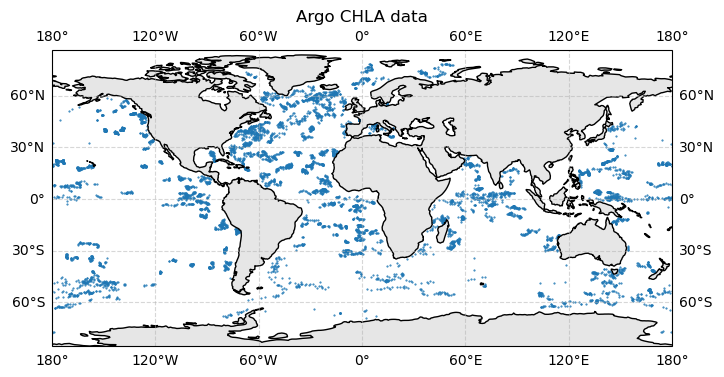

In [19]:
# plot the data
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=proj)

# Add coastlines and land
ax.coastlines(resolution="110m")
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

df_clean = df.dropna(subset=["CHLA_0_10"])

# Add the Argo points from df
ax.scatter(
    df_clean["LONGITUDE"].values,
    df_clean["LATITUDE"].values,
    s=1,
    marker=".",
    transform=proj,
)

ax.set_title("Argo CHLA data")

plt.show()


## Summary

Now we have in-situ CHLA and BBP700 data. For our machine-learning, we need to match these points to PACE data and extract the PACE variables for each lat/lon/time point.

----

## Actual data processing

I saved the ERDDAP data to raw files and then processed into monthly. That way I could try many different summaries of the CHLA data, e.g. surface versus profile.

### Function to get Argo data and return xarray dataset

In [2]:
# get_bgc_surface() function
from pathlib import Path

import numpy as np
import pandas as pd
from argopy import DataFetcher as ArgoDataFetcher

def get_bgc_file(reg, mon, data_dir="data", vars=None, save=False):
    """
    Fetch profile Bio-Argo dataset.
    """
    if vars is None:
        vars = ["CHLA"]  # default behaviour

    # Required base columns in the data from Bio-Argo
    base_cols = [
        "PLATFORM_NUMBER", "CYCLE_NUMBER",
        "TIME", "LATITUDE", "LONGITUDE", "PRES",
    ]

    # De-duplicate and drop any that are base columns (e.g. PRES)
    extra_vars_raw = list(dict.fromkeys(vars))
    extra_vars = [v for v in extra_vars_raw if v not in base_cols]

    lon_min, lon_max, lat_min, lat_max, z_min, z_max = reg

    # Compute start/end of the month
    mon_start = pd.to_datetime(mon).to_period("M").start_time
    mon_end = (mon_start + pd.offsets.MonthBegin(1))

    region = [
        lon_min, lon_max,
        lat_min, lat_max,
        z_min, z_max,
        mon_start.strftime("%Y-%m-%d"),
        mon_end.strftime("%Y-%m-%d"),
    ]

    # STEP 1: Get data for region + month
    # We always request PRES, plus user extras (not TEMP/PSAL unless user asked)
    param_vars = list(dict.fromkeys(extra_vars + ["PRES"]))

    fetcher = ArgoDataFetcher(
        ds="bgc",
        src="erddap",
        params=param_vars,
    )

    try:
        ds = fetcher.region(region).to_xarray()
    except Exception as exc:
        print(f"No data for region={reg}, month={mon}: {exc}")
        # Return empty frame with full schema
        return None

    # Bail if argopy returned an empty ds
    if "N_POINTS" in ds.sizes and ds.sizes["N_POINTS"] == 0:
        print(f"No data rows (N_POINTS=0) for region={reg}, month={mon}")
        return None
    
    # Also guard against “all dims zero”
    if all(size == 0 for size in ds.sizes.values()):
        print(f"No data rows (all dims zero) for region={reg}, month={mon}")
        return None    

    return ds
    

### For loop to get files for each month

Break the globe up into regions and get file for each region/month.

In [ ]:
%%script false --no-raise-error
# Save the raw files so I don't need to keep hitting the erddap server
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Variables to get if avail. NaN if missing
BGC_VARS = ["CHLA"]
out_dir = Path("data/raw")
out_dir.mkdir(parents=True, exist_ok=True)

# Months from 2024-03 up to the current month
start_month = "2024-03"
end_month = pd.Timestamp.today().to_period("M")
months = pd.period_range(start_month, end_month, freq="M")

for mon in months:
    month_str = mon.strftime("%Y-%m")

    print(f"\n=== Processing month {month_str} ===")

    dfs = []  # collect all boxes for this month

    # Latitude: 45° bands from -90 to 90 -> 4 bands
    for lat_min in range(-90, 90, 45):
        lat_max = lat_min + 45

        # Longitude: 60° bands from -180 to 180 -> 6 bands
        for lon_min in range(-180, 180, 60):
            lon_max = lon_min + 60
            region = [lon_min, lon_max, lat_min, lat_max, 0, 200]
            print(f" -- region={region}")
            ds_box = get_bgc_file(region, month_str, vars=BGC_VARS, save=False)
            if ds_box is None: continue
            out_path = out_dir / f"argo_bgc_global_{month_str}_{lon_min}_{lon_max}_{lat_min}_{lat_max}.parquet"
            # Skip if we already have this month (so reruns don't redo everything)
            if out_path.exists():
                print(f"Skipping {month_str}, already have {out_path}")
                continue

            ds_box.to_netcdf(out_path)


### Merge the region/month files into one month file

In [ ]:
%%script false --no-raise-error
# Merge into monthly files for GitHub

from pathlib import Path
import pandas as pd
import xarray as xr

raw_dir = Path("data/raw")          # where the tile .nc files live
out_dir = Path("data/argo_monthly_nc")   # where you want monthly merged .nc
out_dir.mkdir(parents=True, exist_ok=True)

# derive months from existing files
months = sorted({
    f.name.split("_")[3]           # "2024-03" from "argo_bgc_global_2024-03_..."
    for f in raw_dir.glob("argo_bgc_global_*.nc")
})

for month_str in months:
    out_path = out_dir / f"argo_bgc_global_{month_str}.nc"
    if out_path.exists():
        print(f"Skipping {month_str}, already have {out_path}")
        continue

    month_files = sorted(raw_dir.glob(f"argo_bgc_global_{month_str}_*.nc"))
    if not month_files:
        print(f"No tiles found for {month_str}, skipping")
        continue

    print(f"\n=== Merging {len(month_files)} tiles for {month_str} ===")

    # Peek at first file to find the "point" dimension (usually N_POINTS)
    with xr.open_dataset(month_files[0]) as ds0:
        # Prefer N_POINTS if present, otherwise just take the first non-time dim
        if "N_POINTS" in ds0.dims:
            point_dim = "N_POINTS"
        else:
            # fall back: pick first dimension that's not time
            non_time_dims = [d for d in ds0.dims if d.lower() != "time"]
            if not non_time_dims:
                raise ValueError(f"Could not figure out point dim for {month_files[0]}")
            point_dim = non_time_dims[0]

    # Open & concatenate all tiles along the point dimension
    ds_month = xr.open_mfdataset(
        month_files,
        combine="nested",
        concat_dim=point_dim,
        parallel=False,
    )

    # (Optional) sort by time then index if you like
    if "TIME" in ds_month:
        ds_month = ds_month.sortby("TIME")

    ds_month.to_netcdf(out_path)
    ds_month.close()

    print(f"  -> Saved merged monthly file to {out_path}")


In [21]:
# test
import xarray as xr
ds = xr.open_dataset("data/argo_monthly_nc/argo_bgc_global_2024-12.nc")
ds

<xarray.Dataset> Size: 6MB
Dimensions:          (N_POINTS: 39413)
Coordinates:
    LATITUDE         (N_POINTS) float64 315kB ...
    LONGITUDE        (N_POINTS) float64 315kB ...
    TIME             (N_POINTS) datetime64[ns] 315kB ...
  * N_POINTS         (N_POINTS) int64 315kB 0 0 1 2 3 ... 6664 6665 6666 6667
Data variables: (12/21)
    CHLA             (N_POINTS) float32 158kB ...
    CHLA_DATA_MODE   (N_POINTS) <U1 158kB ...
    CHLA_ERROR       (N_POINTS) float32 158kB ...
    CHLA_QC          (N_POINTS) int64 315kB ...
    CYCLE_NUMBER     (N_POINTS) int64 315kB ...
    DIRECTION        (N_POINTS) <U1 158kB ...
    ...               ...
    PSAL_QC          (N_POINTS) int64 315kB ...
    TEMP             (N_POINTS) float32 158kB ...
    TEMP_DATA_MODE   (N_POINTS) <U1 158kB ...
    TEMP_ERROR       (N_POINTS) float32 158kB ...
    TEMP_QC          (N_POINTS) int64 315kB ...
    TIME_QC          (N_POINTS) int64 315kB ...
Attributes:
    DATA_ID:              ARGO-BGC
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           jovyan
    Fetched_date:         2025/11/29
    Fetched_constraints:  [x=-120.00/-60.00; y=-45.00/0.00; z=0.0/200.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [CHLA,PRES,PSAL,TEMP] real-time and adjusted/delaye...

### Create an index file with just the profile meta data

We will use this for doing matchups so we don't have to load more data than needed, e.g. all the profile data.

In [1]:
%%script false --no-raise-error
from pathlib import Path
import xarray as xr
import pandas as pd

var_dir = Path("data/argo_monthly_nc")
files = sorted(var_dir.glob("argo_bgc_global_*.nc"))

profile_rows = []

for f in files:
    print(f"Reading {f}")
    ds = xr.open_dataset(f)

    # Select only the columns we need for the profile index
    needed = ["PLATFORM_NUMBER", "CYCLE_NUMBER", "TIME", "LATITUDE", "LONGITUDE", "CHLA_QC", "PRES"]
    missing = [v for v in needed if v not in ds.variables and v not in ds.coords]
    if missing:
        raise ValueError(f"{f} missing required vars: {missing}")

    df = (
        ds[needed]
        .to_dataframe()
        .reset_index(drop=True)
    )

    # Drop any rows without platform/cycle info
    df = df.dropna(subset=["PLATFORM_NUMBER", "CYCLE_NUMBER"])

    # Collapse to ONE row per (PLATFORM_NUMBER, CYCLE_NUMBER).
    # We just keep:
    #   - TIME: first
    #   - LAT/LON: first (typically constant within profile)
    df_profiles = (
        df
        .sort_values("TIME")  # just to make "first" deterministic
        .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
        .agg({
            "TIME": "first",
            "LATITUDE": "first",
            "LONGITUDE": "first",
        })
    )

    profile_rows.append(df_profiles)

# Combine all months
profiles = pd.concat(profile_rows, ignore_index=True)

# If there is overlap between months, enforce uniqueness
profiles = (
    profiles
    .sort_values("TIME")
    .drop_duplicates(subset=["PLATFORM_NUMBER", "CYCLE_NUMBER"], keep="first")
    .reset_index(drop=True)
)

# Create a stable profile_id: e.g. "6901234_0042"
profiles["profile_id"] = (
    profiles["PLATFORM_NUMBER"].astype(int).astype(str).str.zfill(7)
    + "_"
    + profiles["CYCLE_NUMBER"].astype(int).astype(str).str.zfill(4)
)

# Reorder columns: profile_id first, then metadata
profiles = profiles[
    ["profile_id", "PLATFORM_NUMBER", "CYCLE_NUMBER", "TIME",
     "LATITUDE", "LONGITUDE"]
]

print(len(profiles), "unique profiles")
print(profiles.columns)

# Save for later joins
out_path = var_dir / "argo_profiles_index.parquet"
profiles.to_parquet(out_path, index=False)
print("Wrote", out_path)

## Process files

Now that I have the data locally, we can easily create different metrics.

In [7]:
import xarray as xr
ds = xr.open_dataset("data/argo_monthly_nc/argo_bgc_global_2025-07.nc")

df = ds.to_dataframe().reset_index()

# QC first
#df_qc = df[df["CHLA_QC"].isin([1, 2])]

df_points = (
    df
    .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
    .apply(summarize_profile_binned, var="CHLA", include_meta=True, include_groups=False)   # default 0–200m in 10m bins
    .reset_index(drop=True)
)
df_points.shape

(858, 45)

In [8]:
from pathlib import Path
import xarray as xr

var_dir = Path("data/argo_monthly_nc")
files = sorted(var_dir.glob("argo_bgc_global_*.nc"))

profile_rows = []

for f in files:
    print(f"Reading {f}")
    ds = xr.open_dataset(f)
    df = ds.to_dataframe().reset_index()

    df_profiles = (
        df
        .groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER"], as_index=False)
        .apply(summarize_profile_binned, var="CHLA", include_meta=True, include_groups=False)   # default 0–200m in 10m bins
        .reset_index(drop=True)
    )
    profile_rows.append(df_profiles)

Reading data/argo_monthly_nc/argo_bgc_global_2024-03.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-04.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-05.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-06.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-07.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-08.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-09.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-10.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-11.nc
Reading data/argo_monthly_nc/argo_bgc_global_2024-12.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-01.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-02.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-03.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-04.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-05.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-06.nc
Reading data/argo_monthly_nc/argo_bgc_global_2025-07.nc
Reading data/argo_monthly_nc/argo_bgc_global_202

In [9]:
import pandas as pd
profiles = pd.concat(profile_rows, ignore_index=True)
# Create a stable profile_id: e.g. "6901234_0042"
profiles["profile_id"] = (
    profiles["PLATFORM_NUMBER"].astype(int).astype(str).str.zfill(7)
    + "_"
    + profiles["CYCLE_NUMBER"].astype(int).astype(str).str.zfill(4)
)
out_path = "tutorial_data/CHLA_argo_profiles.parquet"
profiles.to_parquet(out_path, index=False)
